In [1]:
from rdkit import RDLogger
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem import AllChem
from rdkit.Chem import Crippen
from rdkit.Chem.EState import EState_VSA
from rdkit.Chem import rdMolDescriptors
import pandas as pd
import pyrfume
from rdkit import Chem
from rdkit.Chem import QED, Crippen, Descriptors, rdMolDescriptors, AllChem
from rdkit.Chem.Descriptors import MolWt
# Disable RDKit warnings
RDLogger.DisableLog('rdApp.*')


In [2]:
def process_fragrancedb1(input_file, output_file, dataset_name):
    """
    Process the fragrance database, calculate molecular properties, and save results to an Excel file.
    
    Parameters:
    - input_file (str): Path to the input CSV file.
    - output_file (str): Path to save the processed Excel file.
    - calculate_properties (function): Function to compute molecular properties from a SMILES string.
    """
    # Load the dataset
    df = input_file
    df.reset_index(drop=True, inplace=True)
    
    # Define the SMILES column
    smiles_column = 'IsomericSMILES'
    
    if smiles_column not in df.columns:
        print(f"Error: '{smiles_column}' column not found in the CSV file.")
        print("Available columns:", df.columns.tolist())
        return
    
    data = []
    
    # Iterate over each molecule in the dataset
    for index, row in df.iterrows():
        smiles = row[smiles_column]
        properties = calculate_properties(smiles)
        
        if properties:
            # Include all original columns
            for col in df.columns:
                properties[col] = row[col]
            data.append(properties)
        
        # Print progress every 100 molecules
        if (index + 1) % 100 == 0:
            print(f"Processed {index + 1} molecules...")

    # Convert processed data to DataFrame
    result_df = pd.DataFrame(data)
    
    if not result_df.empty:
        # Reorder columns to keep SMILES first
        columns = result_df.columns.tolist()
        columns.remove(smiles_column)
        columns = [smiles_column] + columns
        result_df = result_df[columns]
        
        # Save to Excel
        result_df.to_excel(output_file, index=False)
        
        print(f"PROPERTIES CALCULATED 😊 AND SAVED TO {output_file}")
        print(f"THE SIZE OF 🌻🌼🌸 {dataset_name}  🌻🌼🌸 IN PYRFUME IS {len(df)}")
        print(f"THE TOTAL SIZE OF THE 🌻🌼🌸{dataset_name} 🌻🌼🌸 FOR WHICH MOLECULAR PROPERTY CALCULATED IS {len(result_df)}")
    else:
        print("No valid molecular properties were calculated.")

In [3]:
def calculate_properties(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    properties = {
'QED': QED.qed(mol),
                'logP': Crippen.MolLogP(mol),
                'Molecular Weight': Descriptors.MolWt(mol),
                'Number of Heavy Atoms': Descriptors.HeavyAtomCount(mol),
                'TPSA': Descriptors.TPSA(mol),
                'Rotatable Bonds': Descriptors.NumRotatableBonds(mol),
                'H-bond Donors': Descriptors.NumHDonors(mol),
                'H-bond Acceptors': Descriptors.NumHAcceptors(mol),
                'Ring Count': Descriptors.RingCount(mol),
                'Formal Charge': Chem.GetFormalCharge(mol),
                'Fraction of Sp2 Hybridized Atoms': rdMolDescriptors.CalcFractionCSP3(mol),
                'Number of Aromatic Rings': rdMolDescriptors.CalcNumAromaticRings(mol),
                'Molar Refractivity': Descriptors.MolMR(mol),
                'Rotatable Bond Count': Descriptors.NumRotatableBonds(mol),
                'Number of Heteroatoms': rdMolDescriptors.CalcNumHeteroatoms(mol),
                'Ipc': Descriptors.Ipc(mol),
                'Kappa1': Descriptors.Kappa1(mol),
                'Kappa2': Descriptors.Kappa2(mol),
                'Kappa3': Descriptors.Kappa3(mol),
                'LabuteASA': Descriptors.LabuteASA(mol),
                'PEOE_VSA1': Descriptors.PEOE_VSA1(mol),
                'PEOE_VSA2': Descriptors.PEOE_VSA2(mol),
                'PEOE_VSA3': Descriptors.PEOE_VSA3(mol),
                'SMR_VSA1': Descriptors.SMR_VSA1(mol),
                'SMR_VSA2': Descriptors.SMR_VSA2(mol),
                'SMR_VSA3': Descriptors.SMR_VSA3(mol),
                'SlogP_VSA1': Descriptors.SlogP_VSA1(mol),
                'SlogP_VSA2': Descriptors.SlogP_VSA2(mol),
                'SlogP_VSA3': Descriptors.SlogP_VSA3(mol),
                'FCFP4 Count': len(AllChem.GetMorganFingerprintAsBitVect(mol, 2, useFeatures=True).GetOnBits()),
                'ECFP4 Count': len(AllChem.GetMorganFingerprintAsBitVect(mol, 2, useFeatures=False).GetOnBits()),
                'Num Bridgehead Atoms': rdMolDescriptors.CalcNumBridgeheadAtoms(mol),
                'Num Spiro Atoms': rdMolDescriptors.CalcNumSpiroAtoms(mol),
                'Num Macrocycles': sum(1 for ring in mol.GetRingInfo().AtomRings() if len(ring) > 8),
                'Fsp3': rdMolDescriptors.CalcFractionCSP3(mol),
                'Ring Atom Count': sum(1 for atom in mol.GetAtoms() if atom.IsInRing()),
                'Ring Bond Count': sum(1 for bond in mol.GetBonds() if bond.IsInRing()),
                'Aliphatic Ring Count': rdMolDescriptors.CalcNumAliphaticRings(mol),
                'Aliphatic Heteroatom Count': sum(1 for atom in mol.GetAtoms() if atom.IsInRing() and atom.GetAtomicNum() not in [1, 6]),
                'Aromatic Heteroatom Count': sum(1 for atom in mol.GetAtoms() if atom.GetIsAromatic() and atom.GetAtomicNum() not in [1, 6]),
                'Saturated Ring Count': rdMolDescriptors.CalcNumSaturatedRings(mol),
                'Aromatic Ring Count': rdMolDescriptors.CalcNumAromaticRings(mol),
                'Hetero-Aliphatic Ring Count': rdMolDescriptors.CalcNumAliphaticHeterocycles(mol),
                'Hetero-Aromatic Ring Count': rdMolDescriptors.CalcNumAromaticHeterocycles(mol),
                'Hetero-Saturated Ring Count': rdMolDescriptors.CalcNumSaturatedHeterocycles(mol),
                'Largest Ring Size': max([len(ring) for ring in mol.GetRingInfo().AtomRings()]) if mol.GetRingInfo().AtomRings() else 0,
                'Wildman-Crippen MR': Crippen.MolMR(mol),
                'Average Molecular Weight': Descriptors.MolWt(mol) / mol.GetNumAtoms(),
                'Exact Molecular Weight': Descriptors.ExactMolWt(mol),
                'Atom Pair Fingerprint Count': len(AllChem.GetAtomPairFingerprint(mol).GetNonzeroElements()),                
                'Natural Product Likeness Score': QED.qed(mol),  # Placeholder for NP-likeness
    }
    
    return properties

In [4]:
def process_fragrancedb(input_file, output_file, dataset_name):
    """
    Process the fragrance database, calculate molecular properties, and save results to an Excel file.
    
    Parameters:
    - input_file (str): Path to the input CSV file.
    - output_file (str): Path to save the processed Excel file.
    - calculate_properties (function): Function to compute molecular properties from a SMILES string.
    """
    # Load the dataset
    df = pyrfume.load_data(input_file)
    df.reset_index(drop=True, inplace=True)
    
    # Define the SMILES column
    smiles_column = 'IsomericSMILES'
    
    if smiles_column not in df.columns:
        print(f"Error: '{smiles_column}' column not found in the CSV file.")
        print("Available columns:", df.columns.tolist())
        return
    
    data = []
    
    # Iterate over each molecule in the dataset
    for index, row in df.iterrows():
        smiles = row[smiles_column]
        properties = calculate_properties(smiles)
        
        if properties:
            # Include all original columns
            for col in df.columns:
                properties[col] = row[col]
            data.append(properties)
        
        # Print progress every 100 molecules
        if (index + 1) % 100 == 0:
            print(f"Processed {index + 1} molecules...")

    # Convert processed data to DataFrame
    result_df = pd.DataFrame(data)
    
    if not result_df.empty:
        # Reorder columns to keep SMILES first
        columns = result_df.columns.tolist()
        columns.remove(smiles_column)
        columns = [smiles_column] + columns
        result_df = result_df[columns]
        
        # Save to Excel
        result_df.to_excel(output_file, index=False)
        
        print(f"PROPERTIES CALCULATED 😊 AND SAVED TO {output_file}")
        print(f"THE SIZE OF 🌻🌼🌸 {dataset_name}  🌻🌼🌸 IN PYRFUME IS {len(df)}")
        print(f"THE TOTAL SIZE OF THE 🌻🌼🌸{dataset_name} 🌻🌼🌸 FOR WHICH MOLECULAR PROPERTY CALCULATED IS {len(result_df)}")
    else:
        print("No valid molecular properties were calculated.")

**arctander**
https://github.com/pyrfume/pyrfume-data/blob/main/arctander_1960/manifest.toml

In [5]:
arctander_molecules = pyrfume.load_data("arctander_1960/molecules.csv")
print("The size of arctander is ",len(arctander_molecules ))
print("THE COLOUMNS IN arctander IS",arctander_molecules.columns)
arctander_molecules.head()

The size of arctander is  2751
THE COLOUMNS IN arctander IS Index(['MolecularWeight', 'IsomericSMILES', 'IUPACName', 'name'], dtype='object')


,MolecularWeight,IsomericSMILES,IUPACName,name
CID,,,,
107,150.17,C1=CC=C(C=C1)CCC(=O)O,3-phenylpropanoic acid,hydrocinnamic acid
126,122.12,C1=CC(=CC=C1C=O)O,4-hydroxybenzaldehyde,4-hydroxybenzaldehyde
174,62.07,C(CO)O,"ethane-1,2-diol",ethylene glycol
176,60.05,CC(=O)O,acetic acid,acetic acid
177,44.05,CC=O,acetaldehyde,acetaldehyde


In [6]:
#arctander
input_file = "arctander_1960/molecules.csv"
output_file = "data/fragrance_datasets/arctander/arctander_molecular_properties.xlsx"
dataset_name="arctander"
# Ensure `calculate_properties` is defined before calling the function
process_fragrancedb(input_file, output_file,dataset_name)


Processed 100 molecules...
Processed 200 molecules...
Processed 300 molecules...
Processed 400 molecules...
Processed 500 molecules...
Processed 600 molecules...
Processed 700 molecules...
Processed 800 molecules...
Processed 900 molecules...
Processed 1000 molecules...
Processed 1100 molecules...
Processed 1200 molecules...
Processed 1300 molecules...
Processed 1400 molecules...
Processed 1500 molecules...
Processed 1600 molecules...
Processed 1700 molecules...
Processed 1800 molecules...
Processed 1900 molecules...
Processed 2000 molecules...
Processed 2100 molecules...
Processed 2200 molecules...
Processed 2300 molecules...
Processed 2400 molecules...
Processed 2500 molecules...
Processed 2600 molecules...
Processed 2700 molecules...
PROPERTIES CALCULATED 😊 AND SAVED TO data/fragrance_datasets/arctander/arctander_molecular_properties.xlsx
THE SIZE OF 🌻🌼🌸 arctander  🌻🌼🌸 IN PYRFUME IS 2751
THE TOTAL SIZE OF THE 🌻🌼🌸arctander 🌻🌼🌸 FOR WHICH MOLECULAR PROPERTY CALCULATED IS 2751


**FRAGRANCEDB**
https://github.com/pyrfume/pyrfume-data/blob/main/fragrancedb/manifest.toml

In [7]:

fragrancedb_molecules = pyrfume.load_data("fragrancedb/molecules.csv")
print("The size of fragrancedb is ",len(fragrancedb_molecules ))
print("THE COLOUMNS IN fragrgncedb IS",fragrancedb_molecules.columns)
fragrancedb_molecules.head()

The size of fragrancedb is  1748
THE COLOUMNS IN fragrgncedb IS Index(['MolecularWeight', 'IsomericSMILES', 'IUPACName', 'name'], dtype='object')


,MolecularWeight,IsomericSMILES,IUPACName,name
-972532401375,134.099797,CCCCCC([NH3+])S,NaN,NaN
-937808996977,97.029503,CC1=C([O-])OC=C1,NaN,NaN
-887957258736,182.130680,O=CCCCCCCCC=C1CO1,NaN,NaN
-870225970770,140.083730,O=CCCCCC=C1CO1,NaN,NaN
-858149900965,250.180155,CCCC(CC(=O)OCC)[NH2+]CC1=CC=CC=C1,NaN,NaN


In [8]:
#FRAGRANCEDB
input_file = "fragrancedb/molecules.csv"
output_file = "data/fragrance_datasets/fragrancedb/fragrancedb_molecular_properties.xlsx"
dataset_name="frangrancedb"
# Ensure `calculate_properties` is defined before calling the function
process_fragrancedb(input_file, output_file,dataset_name)


Processed 100 molecules...
Processed 200 molecules...
Processed 300 molecules...
Processed 400 molecules...
Processed 500 molecules...
Processed 600 molecules...
Processed 700 molecules...
Processed 800 molecules...
Processed 900 molecules...
Processed 1000 molecules...
Processed 1100 molecules...
Processed 1200 molecules...
Processed 1300 molecules...
Processed 1400 molecules...
Processed 1500 molecules...
Processed 1600 molecules...
Processed 1700 molecules...
PROPERTIES CALCULATED 😊 AND SAVED TO data/fragrance_datasets/fragrancedb/fragrancedb_molecular_properties.xlsx
THE SIZE OF 🌻🌼🌸 frangrancedb  🌻🌼🌸 IN PYRFUME IS 1748
THE TOTAL SIZE OF THE 🌻🌼🌸frangrancedb 🌻🌼🌸 FOR WHICH MOLECULAR PROPERTY CALCULATED IS 1748


**AROMAEDB**

In [9]:
aroma_db_molecules = pyrfume.load_data("aromadb/molecules.csv")
print("The size of aroma_db is ",len(aroma_db_molecules ))
remove_cids = {
    239, 379, 798, 880, 994, 3322, 5960, 6106, 6274, 6322, 7410, 7478, 7657, 7852, 8060,
    10452, 10659, 10795, 12146, 12779, 13006, 13016, 13594, 16800, 31231, 31268, 61072,
    61097, 61134, 62484, 62510, 62539, 68148, 68284, 73174, 102861, 135215, 520484,
    521246, 543664, 544628, 3782139, 5273469, 5319022, 5352557, 5362563, 5362620,
    5364533, 5371002, 5372174, 5463905, 10608036, 19352744, 20327362, 23001441
}

# Remove rows where CID is in the remove_cids list
filtered_molecules = aroma_db_molecules[~aroma_db_molecules.index.isin(remove_cids)]
aroma_db_molecules=filtered_molecules
# Save the filtered data
#filtered_molecules.to_csv("aromadb/filtered_molecules.csv")

# Display the first few rows of the filtered dataset
print(filtered_molecules.head())
print(aroma_db_molecules.columns)
print("The size of aroma_db after removing odorless comparision is ",len(aroma_db_molecules ))
aroma_db_molecules.head()
# remove some coloumns as the behavir file shows that has label ao aroma
#239,379,798,880,994,3322,5960,6106,6274,6322,7410,7478,7657,7852,8060,10452,10659,10795,12146,12779,13006,13016,13594,16800,31231,31268,

The size of aroma_db is  869
     MolecularWeight         IsomericSMILES                    IUPACName  \
CID                                                                        
49            116.11       CC(C)C(=O)C(=O)O  3-methyl-2-oxobutanoic acid   
107           150.17  C1=CC=C(C=C1)CCC(=O)O       3-phenylpropanoic acid   
126           122.12      C1=CC(=CC=C1C=O)O        4-hydroxybenzaldehyde   
176            60.05                CC(=O)O                  acetic acid   
177            44.05                   CC=O                 acetaldehyde   

                            name  
CID                               
49   3-methyl-2-oxobutanoic acid  
107           hydrocinnamic acid  
126        4-hydroxybenzaldehyde  
176                  acetic acid  
177                 acetaldehyde  
Index(['MolecularWeight', 'IsomericSMILES', 'IUPACName', 'name'], dtype='object')
The size of aroma_db after removing odorless comparision is  814


,MolecularWeight,IsomericSMILES,IUPACName,name
CID,,,,
49,116.11,CC(C)C(=O)C(=O)O,3-methyl-2-oxobutanoic acid,3-methyl-2-oxobutanoic acid
107,150.17,C1=CC=C(C=C1)CCC(=O)O,3-phenylpropanoic acid,hydrocinnamic acid
126,122.12,C1=CC(=CC=C1C=O)O,4-hydroxybenzaldehyde,4-hydroxybenzaldehyde
176,60.05,CC(=O)O,acetic acid,acetic acid
177,44.05,CC=O,acetaldehyde,acetaldehyde


In [10]:
#AROMADBDB
input_file = aroma_db_molecules
output_file = "data/fragrance_datasets/aromadb/fragrancedb_molecular_properties.xlsx"
dataset_name="aromadb"
# Ensure `calculate_properties` is defined before calling the function
process_fragrancedb1(input_file, output_file,dataset_name)

Processed 100 molecules...
Processed 200 molecules...
Processed 300 molecules...
Processed 400 molecules...
Processed 500 molecules...
Processed 600 molecules...
Processed 700 molecules...
Processed 800 molecules...
PROPERTIES CALCULATED 😊 AND SAVED TO data/fragrance_datasets/aromadb/fragrancedb_molecular_properties.xlsx
THE SIZE OF 🌻🌼🌸 aromadb  🌻🌼🌸 IN PYRFUME IS 814
THE TOTAL SIZE OF THE 🌻🌼🌸aromadb 🌻🌼🌸 FOR WHICH MOLECULAR PROPERTY CALCULATED IS 814


**superscent**

In [11]:
superscent_db_molecules = pyrfume.load_data("superscent/molecules.csv")
print("The size of superscent_db is ",len(superscent_db_molecules ))
print(superscent_db_molecules.columns)
superscent_db_molecules.head()

The size of superscent_db is  1589
Index(['MolecularWeight', 'IsomericSMILES', 'IUPACName', 'name'], dtype='object')


,MolecularWeight,IsomericSMILES,IUPACName,name
CID,,,,
58,102.09,CCC(=O)C(=O)O,2-oxobutanoic acid,2-oxobutanoic acid
107,150.17,C1=CC=C(C=C1)CCC(=O)O,3-phenylpropanoic acid,hydrocinnamic acid
125,124.14,C1=CC(=CC=C1CO)O,4-(hydroxymethyl)phenol,4-hydroxybenzyl alcohol
126,122.12,C1=CC(=CC=C1C=O)O,4-hydroxybenzaldehyde,4-hydroxybenzaldehyde
135,138.12,C1=CC(=CC=C1C(=O)O)O,4-hydroxybenzoic acid,4-hydroxybenzoic acid


In [12]:
input_file = "superscent/molecules.csv"
output_file = "data/fragrance_datasets/superscent/fragrancedb_molecular_properties.xlsx"
dataset_name="superscent"
# Ensure `calculate_properties` is defined before calling the function
process_fragrancedb(input_file, output_file,dataset_name)

Processed 100 molecules...
Processed 200 molecules...
Processed 300 molecules...
Processed 400 molecules...
Processed 500 molecules...
Processed 600 molecules...
Processed 700 molecules...
Processed 800 molecules...
Processed 900 molecules...
Processed 1000 molecules...
Processed 1100 molecules...
Processed 1200 molecules...
Processed 1300 molecules...
Processed 1400 molecules...
Processed 1500 molecules...
PROPERTIES CALCULATED 😊 AND SAVED TO data/fragrance_datasets/superscent/fragrancedb_molecular_properties.xlsx
THE SIZE OF 🌻🌼🌸 superscent  🌻🌼🌸 IN PYRFUME IS 1589
THE TOTAL SIZE OF THE 🌻🌼🌸superscent 🌻🌼🌸 FOR WHICH MOLECULAR PROPERTY CALCULATED IS 1589


**flavordb**

In [13]:
flavordb_db_molecules = pyrfume.load_data("flavordb/molecules.csv")
print("The size of flavor_db is ",len(flavordb_db_molecules ))
print(flavordb_db_molecules.columns)
flavordb_db_molecules.head()

The size of flavor_db is  25595
Index(['MolecularWeight', 'IsomericSMILES', 'IUPACName', 'name'], dtype='object')


,MolecularWeight,IsomericSMILES,IUPACName,name
CID,,,,
4,75.11,CC(CN)O,1-aminopropan-2-ol,1-aminopropan-2-ol
40,164.16,C1C(C(C(OC1O)CO)O)O,"6-(hydroxymethyl)oxane-2,4,5-triol",mls002638629
47,130.14,CCC(C)C(=O)C(=O)O,3-methyl-2-oxopentanoic acid,3-methyl-2-oxovaleric acid
49,116.11,CC(C)C(=O)C(=O)O,3-methyl-2-oxobutanoic acid,3-methyl-2-oxobutanoic acid
51,146.10,C(CC(=O)O)C(=O)C(=O)O,2-oxopentanedioic acid,2-ketoglutaric acid


In [14]:
input_file = "flavordb/molecules.csv"
output_file = "data/fragrance_datasets/flavordb/fragrancedb_molecular_properties.xlsx"
dataset_name="flavordb"
# Ensure `calculate_properties` is defined before calling the function
process_fragrancedb(input_file, output_file,dataset_name)

Processed 100 molecules...
Processed 200 molecules...
Processed 300 molecules...
Processed 400 molecules...
Processed 500 molecules...
Processed 600 molecules...
Processed 700 molecules...
Processed 800 molecules...
Processed 900 molecules...
Processed 1000 molecules...
Processed 1100 molecules...
Processed 1200 molecules...
Processed 1300 molecules...
Processed 1400 molecules...
Processed 1500 molecules...
Processed 1600 molecules...
Processed 1700 molecules...
Processed 1800 molecules...
Processed 1900 molecules...
Processed 2000 molecules...
Processed 2100 molecules...
Processed 2200 molecules...
Processed 2300 molecules...
Processed 2400 molecules...
Processed 2500 molecules...
Processed 2600 molecules...
Processed 2700 molecules...
Processed 2800 molecules...
Processed 2900 molecules...
Processed 3000 molecules...
Processed 3100 molecules...
Processed 3200 molecules...
Processed 3300 molecules...
Processed 3400 molecules...
Processed 3500 molecules...
Processed 3600 molecules...
P

In [17]:
# import pandas as pd
# import numpy as np
# import joblib
# from sklearn.preprocessing import StandardScaler

# import joblib
# import matplotlib.pyplot as plt
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

# # Load the saved model and scaler
# model = joblib.load('frag_likeliness_model.joblib')
# scaler = joblib.load('feature_scaler.joblib')

# # Load new dataset
# new_data = pd.read_excel('data/fragrance_datasets/superscent/fragrancedb_molecular_properties.xlsx')

# # Ensure the new dataset has the same top 5 selected features
# top_feature_names = ['logP',
#  'Molecular Weight',
#  'SlogP_VSA3',
#  'Fraction of Sp2 Hybridized Atoms',
#  'FCFP4 Count']
# X_new = new_data[top_feature_names]

# # Ensure all features are numeric
# X_new = X_new.select_dtypes(include=[np.number])

# # Scale the features using the same scaler
# X_new_scaled = scaler.transform(X_new)
# # Predict frag_likeliness
# y_new_pred = model.predict(X_new_scaled)
# y_new_pred_prob = model.predict_proba(X_new_scaled)[:, 1]  # Probability of being fragrant

# # If actual labels are available, evaluate the model
# if 'frag_likeliness' in new_data.columns:
#     y_true = new_data['frag_likeliness']

#     # Calculate evaluation metrics
#     accuracy = accuracy_score(y_true, y_new_pred)
#     precision = precision_score(y_true, y_new_pred)
#     recall = recall_score(y_true, y_new_pred)
#     f1 = f1_score(y_true, y_new_pred)
#     roc_auc = roc_auc_score(y_true, y_new_pred_prob)

#     print("\nModel Evaluation on New Data:")
#     print(f"Accuracy: {accuracy:.4f}")
#     print(f"Precision: {precision:.4f}")
#     print(f"Recall: {recall:.4f}")
#     print(f"F1 Score: {f1:.4f}")
#     print(f"ROC AUC Score: {roc_auc:.4f}")

#     # Plot AUROC curve
#     fpr, tpr, _ = roc_curve(y_true, y_new_pred_prob)
#     plt.figure(figsize=(7, 5))
#     plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
#     plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Random classifier line
#     plt.xlabel('False Positive Rate')
#     plt.ylabel('True Positive Rate')
#     plt.title('Receiver Operating Characteristic (ROC) Curve')
#     plt.legend(loc='lower right')
#     plt.show()




# # Add predictions to the dataset
# new_data['frag_likeliness_prediction'] = y_new_pred
# new_data['frag_likeliness_probability'] = y_new_pred_prob

# # Save the predictions
# new_data.to_excel('data/fragrance_datasets/superscent/fragrancedb_predictions.xlsx', index=False)

# print("Predictions saved to 'data/fragrance_datasets/superscent/fragrancedb_predictions.xlsx'")


Predictions saved to 'data/fragrance_datasets/superscent/fragrancedb_predictions.xlsx'



Prediction Equation:
frag_likeliness = -3.6592 + (7.0771 * logP) + (-6.2811 * Molecular Weight) + (1.1403 * SlogP_VSA3) + (0.5869 * Fraction of Sp2 Hybridized Atoms) + (1.9262 * FCFP4 Count)
Successfully loaded data/fragrance_datasets/superscent/fragrancedb_molecular_properties.xlsx
Dataset contains 1589 samples

Predicted Probability Statistics:
Min: 0.0000
Max: 0.9963
Mean: 0.8316
Median: 0.9202
Standard Deviation: 0.2176
Positive predictions: 1444/1589 (90.87%)

Performance Metrics (assuming all true labels are 1):
Accuracy: 0.9087
Precision: 1.0000
Recall: 0.9087
F1 Score: 0.9522


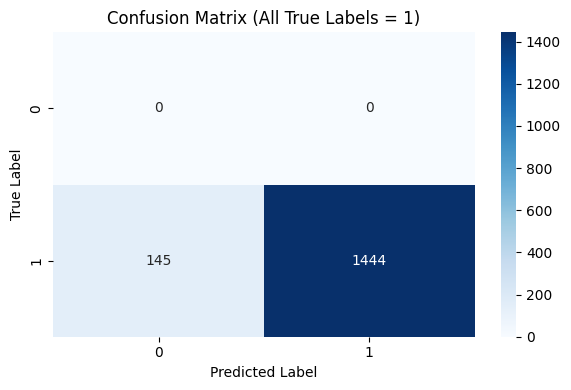


Metric Explanations:
Accuracy: % of compounds correctly identified (% predicted as fragrant)
Precision: Always 1.0 when all true labels are 1 (all positive predictions are correct)
Recall: % of fragrant compounds identified (same as accuracy)
F1 Score: Harmonic mean of precision and recall

Out of 1589 compounds (all assumed fragrant):
- Correctly identified as fragrant (True Positives): 1444
- Incorrectly identified as non-fragrant (False Negatives): 145

Predictions and metrics saved to 'data/fragrance_datasets/superscent/fragrancedb_predictions.xlsx'


In [19]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import seaborn as sns

# Function to plot confusion matrix
def plot_confusion_matrix(cm, classes, title='Confusion Matrix', cmap=plt.cm.Blues):
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

# Load the saved model and scaler
model = joblib.load('frag_likeliness_model.joblib')
scaler = joblib.load('feature_scaler.joblib')

# Get the top features and coefficients
coefficients = model.coef_[0]
intercept = model.intercept_[0]

# Top 5 features from your previous code
top_feature_names = ['logP',
                     'Molecular Weight',
                     'SlogP_VSA3',
                     'Fraction of Sp2 Hybridized Atoms',
                     'FCFP4 Count']

# Print the equation
equation = f"frag_likeliness = {intercept:.4f}"
for feature, coef in zip(top_feature_names, coefficients):
    equation += f" + ({coef:.4f} * {feature})"
print("\nPrediction Equation:")
print(equation)

# Load the actual dataset
file_path = 'data/fragrance_datasets/superscent/fragrancedb_molecular_properties.xlsx'
try:
    data = pd.read_excel(file_path)
    print(f"Successfully loaded {file_path}")
    print(f"Dataset contains {len(data)} samples")
except Exception as e:
    print(f"Error loading file: {e}")
    exit()

# Check if all required features are present
missing_features = [f for f in top_feature_names if f not in data.columns]
if missing_features:
    print(f"Warning: Missing features in dataset: {missing_features}")
    print("Please ensure your dataset contains all these features.")
    exit()

# Select only the top 5 features
X = data[top_feature_names]

# Ensure all features are numeric
X = X.select_dtypes(include=[np.number])

# Scale the features using the same scaler
X_scaled = scaler.transform(X)

# Manual calculation using the equation
z_values = intercept + np.dot(X_scaled, coefficients)
probabilities = 1 / (1 + np.exp(-z_values))
predictions = (probabilities >= 0.5).astype(int)

# Summary statistics of predicted probabilities
print("\nPredicted Probability Statistics:")
print(f"Min: {probabilities.min():.4f}")
print(f"Max: {probabilities.max():.4f}")
print(f"Mean: {probabilities.mean():.4f}")
print(f"Median: {np.median(probabilities):.4f}")
print(f"Standard Deviation: {np.std(probabilities):.4f}")

# Count of positive predictions
positive_count = np.sum(predictions)
total_count = len(predictions)
print(f"Positive predictions: {positive_count}/{total_count} ({positive_count/total_count:.2%})")

# # Create a histogram of the probabilities
# plt.figure(figsize=(10, 6))
# plt.hist(probabilities, bins=20, alpha=0.7, color='blue')
# plt.axvline(x=0.5, color='red', linestyle='--', label='Decision Threshold (0.5)')
# plt.xlabel('Predicted Probability of Being Fragrant')
# plt.ylabel('Count')
# plt.title('Distribution of Predicted Fragrance Probabilities')
# plt.legend()
# plt.grid(axis='y', alpha=0.3)
# plt.tight_layout()
# plt.show()

# Assign all true labels as 1
all_ones = np.ones(len(predictions))

# Calculate performance metrics
accuracy = accuracy_score(all_ones, predictions)
precision = precision_score(all_ones, predictions, zero_division=1)
recall = recall_score(all_ones, predictions, zero_division=1)
f1 = f1_score(all_ones, predictions, zero_division=1)

print("\nPerformance Metrics (assuming all true labels are 1):")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Create confusion matrix
cm = confusion_matrix(all_ones, predictions)
plot_confusion_matrix(cm, classes=[0, 1], title='Confusion Matrix (All True Labels = 1)')

# Explanation of metrics
print("\nMetric Explanations:")
print("Accuracy: % of compounds correctly identified (% predicted as fragrant)")
print("Precision: Always 1.0 when all true labels are 1 (all positive predictions are correct)")
print("Recall: % of fragrant compounds identified (same as accuracy)")
print("F1 Score: Harmonic mean of precision and recall")

# Detailed breakdown of predictions
false_negatives = total_count - positive_count
print(f"\nOut of {total_count} compounds (all assumed fragrant):")
print(f"- Correctly identified as fragrant (True Positives): {positive_count}")
print(f"- Incorrectly identified as non-fragrant (False Negatives): {false_negatives}")

# Add predictions to the dataset
data['frag_likeliness_prediction'] = predictions
data['frag_likeliness_probability'] = probabilities
data['frag_likeliness_z_value'] = z_values

# Save the predictions to a new file
output_path = 'data/fragrance_datasets/superscent/fragrancedb_predictions.xlsx'
data.to_excel(output_path, index=False)
print(f"\nPredictions and metrics saved to '{output_path}'")


Prediction Equation:
frag_likeliness = -3.6592 + (7.0771 * logP) + (-6.2811 * Molecular Weight) + (1.1403 * SlogP_VSA3) + (0.5869 * Fraction of Sp2 Hybridized Atoms) + (1.9262 * FCFP4 Count)
Successfully loaded data/fragrance_datasets/fragrancedb/fragrancedb_molecular_properties.xlsx
Dataset contains 1748 samples

Predicted Probability Statistics:
Min: 0.0000
Max: 0.9963
Mean: 0.8187
Median: 0.9152
Standard Deviation: 0.2290
Positive predictions: 1565/1748 (89.53%)

Performance Metrics (assuming all true labels are 1):
Accuracy: 0.8953
Precision: 1.0000
Recall: 0.8953
F1 Score: 0.9448


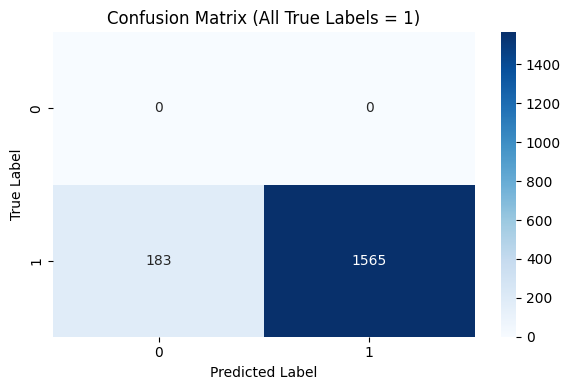


Metric Explanations:
Accuracy: % of compounds correctly identified (% predicted as fragrant)
Precision: Always 1.0 when all true labels are 1 (all positive predictions are correct)
Recall: % of fragrant compounds identified (same as accuracy)
F1 Score: Harmonic mean of precision and recall

Out of 1748 compounds (all assumed fragrant):
- Correctly identified as fragrant (True Positives): 1565
- Incorrectly identified as non-fragrant (False Negatives): 183

Predictions and metrics saved to 'data/fragrance_datasets/fragrancedb/fragrancedb_predictions.xlsx'


In [20]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import seaborn as sns

# Function to plot confusion matrix
def plot_confusion_matrix(cm, classes, title='Confusion Matrix', cmap=plt.cm.Blues):
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

# Load the saved model and scaler
model = joblib.load('frag_likeliness_model.joblib')
scaler = joblib.load('feature_scaler.joblib')

# Get the top features and coefficients
coefficients = model.coef_[0]
intercept = model.intercept_[0]

# Top 5 features from your previous code
top_feature_names = ['logP',
                     'Molecular Weight',
                     'SlogP_VSA3',
                     'Fraction of Sp2 Hybridized Atoms',
                     'FCFP4 Count']

# Print the equation
equation = f"frag_likeliness = {intercept:.4f}"
for feature, coef in zip(top_feature_names, coefficients):
    equation += f" + ({coef:.4f} * {feature})"
print("\nPrediction Equation:")
print(equation)

# Load the actual dataset
file_path = 'data/fragrance_datasets/fragrancedb/fragrancedb_molecular_properties.xlsx'
try:
    data = pd.read_excel(file_path)
    print(f"Successfully loaded {file_path}")
    print(f"Dataset contains {len(data)} samples")
except Exception as e:
    print(f"Error loading file: {e}")
    exit()

# Check if all required features are present
missing_features = [f for f in top_feature_names if f not in data.columns]
if missing_features:
    print(f"Warning: Missing features in dataset: {missing_features}")
    print("Please ensure your dataset contains all these features.")
    exit()

# Select only the top 5 features
X = data[top_feature_names]

# Ensure all features are numeric
X = X.select_dtypes(include=[np.number])

# Scale the features using the same scaler
X_scaled = scaler.transform(X)

# Manual calculation using the equation
z_values = intercept + np.dot(X_scaled, coefficients)
probabilities = 1 / (1 + np.exp(-z_values))
predictions = (probabilities >= 0.5).astype(int)

# Summary statistics of predicted probabilities
print("\nPredicted Probability Statistics:")
print(f"Min: {probabilities.min():.4f}")
print(f"Max: {probabilities.max():.4f}")
print(f"Mean: {probabilities.mean():.4f}")
print(f"Median: {np.median(probabilities):.4f}")
print(f"Standard Deviation: {np.std(probabilities):.4f}")

# Count of positive predictions
positive_count = np.sum(predictions)
total_count = len(predictions)
print(f"Positive predictions: {positive_count}/{total_count} ({positive_count/total_count:.2%})")

# # Create a histogram of the probabilities
# plt.figure(figsize=(10, 6))
# plt.hist(probabilities, bins=20, alpha=0.7, color='blue')
# plt.axvline(x=0.5, color='red', linestyle='--', label='Decision Threshold (0.5)')
# plt.xlabel('Predicted Probability of Being Fragrant')
# plt.ylabel('Count')
# plt.title('Distribution of Predicted Fragrance Probabilities')
# plt.legend()
# plt.grid(axis='y', alpha=0.3)
# plt.tight_layout()
# plt.show()

# Assign all true labels as 1
all_ones = np.ones(len(predictions))

# Calculate performance metrics
accuracy = accuracy_score(all_ones, predictions)
precision = precision_score(all_ones, predictions, zero_division=1)
recall = recall_score(all_ones, predictions, zero_division=1)
f1 = f1_score(all_ones, predictions, zero_division=1)

print("\nPerformance Metrics (assuming all true labels are 1):")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Create confusion matrix
cm = confusion_matrix(all_ones, predictions)
plot_confusion_matrix(cm, classes=[0, 1], title='Confusion Matrix (All True Labels = 1)')

# Explanation of metrics
print("\nMetric Explanations:")
print("Accuracy: % of compounds correctly identified (% predicted as fragrant)")
print("Precision: Always 1.0 when all true labels are 1 (all positive predictions are correct)")
print("Recall: % of fragrant compounds identified (same as accuracy)")
print("F1 Score: Harmonic mean of precision and recall")

# Detailed breakdown of predictions
false_negatives = total_count - positive_count
print(f"\nOut of {total_count} compounds (all assumed fragrant):")
print(f"- Correctly identified as fragrant (True Positives): {positive_count}")
print(f"- Incorrectly identified as non-fragrant (False Negatives): {false_negatives}")

# Add predictions to the dataset
data['frag_likeliness_prediction'] = predictions
data['frag_likeliness_probability'] = probabilities
data['frag_likeliness_z_value'] = z_values

# Save the predictions to a new file
output_path = 'data/fragrance_datasets/fragrancedb/fragrancedb_predictions.xlsx'
data.to_excel(output_path, index=False)
print(f"\nPredictions and metrics saved to '{output_path}'")


Prediction Equation:
frag_likeliness = -3.6592 + (7.0771 * logP) + (-6.2811 * Molecular Weight) + (1.1403 * SlogP_VSA3) + (0.5869 * Fraction of Sp2 Hybridized Atoms) + (1.9262 * FCFP4 Count)
Successfully loaded data/fragrance_datasets/aromadb/fragrancedb_molecular_properties.xlsx
Dataset contains 814 samples

Predicted Probability Statistics:
Min: 0.0062
Max: 0.9958
Mean: 0.8585
Median: 0.9248
Standard Deviation: 0.1699
Positive predictions: 770/814 (94.59%)

Performance Metrics (assuming all true labels are 1):
Accuracy: 0.9459
Precision: 1.0000
Recall: 0.9459
F1 Score: 0.9722


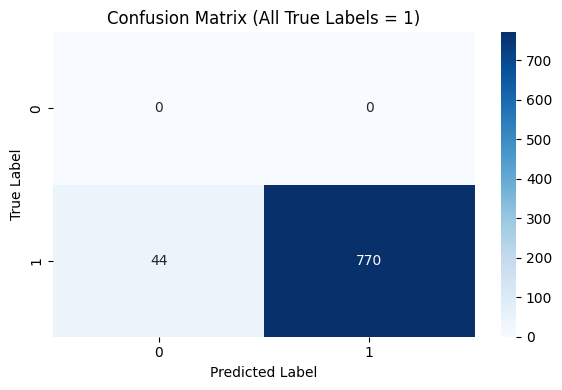


Metric Explanations:
Accuracy: % of compounds correctly identified (% predicted as fragrant)
Precision: Always 1.0 when all true labels are 1 (all positive predictions are correct)
Recall: % of fragrant compounds identified (same as accuracy)
F1 Score: Harmonic mean of precision and recall

Out of 814 compounds (all assumed fragrant):
- Correctly identified as fragrant (True Positives): 770
- Incorrectly identified as non-fragrant (False Negatives): 44

Predictions and metrics saved to 'data/fragrance_datasets/aromadb/fragrancedb_predictions.xlsx'


In [21]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import seaborn as sns

# Function to plot confusion matrix
def plot_confusion_matrix(cm, classes, title='Confusion Matrix', cmap=plt.cm.Blues):
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

# Load the saved model and scaler
model = joblib.load('frag_likeliness_model.joblib')
scaler = joblib.load('feature_scaler.joblib')

# Get the top features and coefficients
coefficients = model.coef_[0]
intercept = model.intercept_[0]

# Top 5 features from your previous code
top_feature_names = ['logP',
                     'Molecular Weight',
                     'SlogP_VSA3',
                     'Fraction of Sp2 Hybridized Atoms',
                     'FCFP4 Count']

# Print the equation
equation = f"frag_likeliness = {intercept:.4f}"
for feature, coef in zip(top_feature_names, coefficients):
    equation += f" + ({coef:.4f} * {feature})"
print("\nPrediction Equation:")
print(equation)

# Load the actual dataset
file_path = 'data/fragrance_datasets/aromadb/fragrancedb_molecular_properties.xlsx'
try:
    data = pd.read_excel(file_path)
    print(f"Successfully loaded {file_path}")
    print(f"Dataset contains {len(data)} samples")
except Exception as e:
    print(f"Error loading file: {e}")
    exit()

# Check if all required features are present
missing_features = [f for f in top_feature_names if f not in data.columns]
if missing_features:
    print(f"Warning: Missing features in dataset: {missing_features}")
    print("Please ensure your dataset contains all these features.")
    exit()

# Select only the top 5 features
X = data[top_feature_names]

# Ensure all features are numeric
X = X.select_dtypes(include=[np.number])

# Scale the features using the same scaler
X_scaled = scaler.transform(X)

# Manual calculation using the equation
z_values = intercept + np.dot(X_scaled, coefficients)
probabilities = 1 / (1 + np.exp(-z_values))
predictions = (probabilities >= 0.5).astype(int)

# Summary statistics of predicted probabilities
print("\nPredicted Probability Statistics:")
print(f"Min: {probabilities.min():.4f}")
print(f"Max: {probabilities.max():.4f}")
print(f"Mean: {probabilities.mean():.4f}")
print(f"Median: {np.median(probabilities):.4f}")
print(f"Standard Deviation: {np.std(probabilities):.4f}")

# Count of positive predictions
positive_count = np.sum(predictions)
total_count = len(predictions)
print(f"Positive predictions: {positive_count}/{total_count} ({positive_count/total_count:.2%})")

# # Create a histogram of the probabilities
# plt.figure(figsize=(10, 6))
# plt.hist(probabilities, bins=20, alpha=0.7, color='blue')
# plt.axvline(x=0.5, color='red', linestyle='--', label='Decision Threshold (0.5)')
# plt.xlabel('Predicted Probability of Being Fragrant')
# plt.ylabel('Count')
# plt.title('Distribution of Predicted Fragrance Probabilities')
# plt.legend()
# plt.grid(axis='y', alpha=0.3)
# plt.tight_layout()
# plt.show()

# Assign all true labels as 1
all_ones = np.ones(len(predictions))

# Calculate performance metrics
accuracy = accuracy_score(all_ones, predictions)
precision = precision_score(all_ones, predictions, zero_division=1)
recall = recall_score(all_ones, predictions, zero_division=1)
f1 = f1_score(all_ones, predictions, zero_division=1)

print("\nPerformance Metrics (assuming all true labels are 1):")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Create confusion matrix
cm = confusion_matrix(all_ones, predictions)
plot_confusion_matrix(cm, classes=[0, 1], title='Confusion Matrix (All True Labels = 1)')

# Explanation of metrics
print("\nMetric Explanations:")
print("Accuracy: % of compounds correctly identified (% predicted as fragrant)")
print("Precision: Always 1.0 when all true labels are 1 (all positive predictions are correct)")
print("Recall: % of fragrant compounds identified (same as accuracy)")
print("F1 Score: Harmonic mean of precision and recall")

# Detailed breakdown of predictions
false_negatives = total_count - positive_count
print(f"\nOut of {total_count} compounds (all assumed fragrant):")
print(f"- Correctly identified as fragrant (True Positives): {positive_count}")
print(f"- Incorrectly identified as non-fragrant (False Negatives): {false_negatives}")

# Add predictions to the dataset
data['frag_likeliness_prediction'] = predictions
data['frag_likeliness_probability'] = probabilities
data['frag_likeliness_z_value'] = z_values

# Save the predictions to a new file
output_path = 'data/fragrance_datasets/aromadb/fragrancedb_predictions.xlsx'
data.to_excel(output_path, index=False)
print(f"\nPredictions and metrics saved to '{output_path}'")


Prediction Equation:
frag_likeliness = -3.6592 + (7.0771 * logP) + (-6.2811 * Molecular Weight) + (1.1403 * SlogP_VSA3) + (0.5869 * Fraction of Sp2 Hybridized Atoms) + (1.9262 * FCFP4 Count)
Successfully loaded data/fragrance_datasets/flavordb/fragrancedb_molecular_properties.xlsx
Dataset contains 25595 samples

Predicted Probability Statistics:
Min: 0.0000
Max: 0.9958
Mean: 0.1193
Median: 0.0001
Standard Deviation: 0.2870
Positive predictions: 3104/25595 (12.13%)

Performance Metrics (assuming all true labels are 1):
Accuracy: 0.1213
Precision: 1.0000
Recall: 0.1213
F1 Score: 0.2163


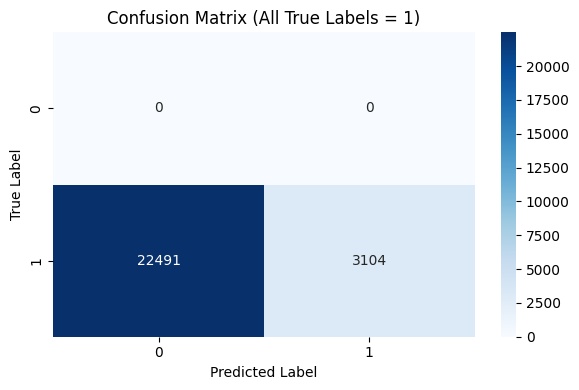


Metric Explanations:
Accuracy: % of compounds correctly identified (% predicted as fragrant)
Precision: Always 1.0 when all true labels are 1 (all positive predictions are correct)
Recall: % of fragrant compounds identified (same as accuracy)
F1 Score: Harmonic mean of precision and recall

Out of 25595 compounds (all assumed fragrant):
- Correctly identified as fragrant (True Positives): 3104
- Incorrectly identified as non-fragrant (False Negatives): 22491

Predictions and metrics saved to 'data/fragrance_datasets/flavordb/fragrancedb_predictions.xlsx'


In [22]:
# import pandas as pd
# import numpy as np
# import joblib
# import matplotlib.pyplot as plt
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
# import seaborn as sns

# # Function to plot confusion matrix
# def plot_confusion_matrix(cm, classes, title='Confusion Matrix', cmap=plt.cm.Blues):
#     plt.figure(figsize=(6, 4))
#     sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, xticklabels=classes, yticklabels=classes)
#     plt.title(title)
#     plt.ylabel('True Label')
#     plt.xlabel('Predicted Label')
#     plt.tight_layout()
#     plt.show()

# # Load the saved model and scaler
# model = joblib.load('frag_likeliness_model.joblib')
# scaler = joblib.load('feature_scaler.joblib')

# # Get the top features and coefficients
# coefficients = model.coef_[0]
# intercept = model.intercept_[0]

# # Top 5 features from your previous code
# top_feature_names = ['logP',
#                      'Molecular Weight',
#                      'SlogP_VSA3',
#                      'Fraction of Sp2 Hybridized Atoms',
#                      'FCFP4 Count']

# # Print the equation
# equation = f"frag_likeliness = {intercept:.4f}"
# for feature, coef in zip(top_feature_names, coefficients):
#     equation += f" + ({coef:.4f} * {feature})"
# print("\nPrediction Equation:")
# print(equation)

# # Load the actual dataset
# file_path = 'data/fragrance_datasets/flavordb/fragrancedb_molecular_properties.xlsx'
# try:
#     data = pd.read_excel(file_path)
#     print(f"Successfully loaded {file_path}")
#     print(f"Dataset contains {len(data)} samples")
# except Exception as e:
#     print(f"Error loading file: {e}")
#     exit()

# # Check if all required features are present
# missing_features = [f for f in top_feature_names if f not in data.columns]
# if missing_features:
#     print(f"Warning: Missing features in dataset: {missing_features}")
#     print("Please ensure your dataset contains all these features.")
#     exit()

# # Select only the top 5 features
# X = data[top_feature_names]

# # Ensure all features are numeric
# X = X.select_dtypes(include=[np.number])

# # Scale the features using the same scaler
# X_scaled = scaler.transform(X)

# # Manual calculation using the equation
# z_values = intercept + np.dot(X_scaled, coefficients)
# probabilities = 1 / (1 + np.exp(-z_values))
# predictions = (probabilities >= 0.5).astype(int)

# # Summary statistics of predicted probabilities
# print("\nPredicted Probability Statistics:")
# print(f"Min: {probabilities.min():.4f}")
# print(f"Max: {probabilities.max():.4f}")
# print(f"Mean: {probabilities.mean():.4f}")
# print(f"Median: {np.median(probabilities):.4f}")
# print(f"Standard Deviation: {np.std(probabilities):.4f}")

# # Count of positive predictions
# positive_count = np.sum(predictions)
# total_count = len(predictions)
# print(f"Positive predictions: {positive_count}/{total_count} ({positive_count/total_count:.2%})")

# # # Create a histogram of the probabilities
# # plt.figure(figsize=(10, 6))
# # plt.hist(probabilities, bins=20, alpha=0.7, color='blue')
# # plt.axvline(x=0.5, color='red', linestyle='--', label='Decision Threshold (0.5)')
# # plt.xlabel('Predicted Probability of Being Fragrant')
# # plt.ylabel('Count')
# # plt.title('Distribution of Predicted Fragrance Probabilities')
# # plt.legend()
# # plt.grid(axis='y', alpha=0.3)
# # plt.tight_layout()
# # plt.show()

# # Assign all true labels as 1
# all_ones = np.ones(len(predictions))

# # Calculate performance metrics
# accuracy = accuracy_score(all_ones, predictions)
# precision = precision_score(all_ones, predictions, zero_division=1)
# recall = recall_score(all_ones, predictions, zero_division=1)
# f1 = f1_score(all_ones, predictions, zero_division=1)

# print("\nPerformance Metrics (assuming all true labels are 1):")
# print(f"Accuracy: {accuracy:.4f}")
# print(f"Precision: {precision:.4f}")
# print(f"Recall: {recall:.4f}")
# print(f"F1 Score: {f1:.4f}")

# # Create confusion matrix
# cm = confusion_matrix(all_ones, predictions)
# plot_confusion_matrix(cm, classes=[0, 1], title='Confusion Matrix (All True Labels = 1)')

# # Explanation of metrics
# print("\nMetric Explanations:")
# print("Accuracy: % of compounds correctly identified (% predicted as fragrant)")
# print("Precision: Always 1.0 when all true labels are 1 (all positive predictions are correct)")
# print("Recall: % of fragrant compounds identified (same as accuracy)")
# print("F1 Score: Harmonic mean of precision and recall")

# # Detailed breakdown of predictions
# false_negatives = total_count - positive_count
# print(f"\nOut of {total_count} compounds (all assumed fragrant):")
# print(f"- Correctly identified as fragrant (True Positives): {positive_count}")
# print(f"- Incorrectly identified as non-fragrant (False Negatives): {false_negatives}")

# # Add predictions to the dataset
# data['frag_likeliness_prediction'] = predictions
# data['frag_likeliness_probability'] = probabilities
# data['frag_likeliness_z_value'] = z_values

# # Save the predictions to a new file
# output_path = 'data/fragrance_datasets/flavordb/fragrancedb_predictions.xlsx'
# data.to_excel(output_path, index=False)
# print(f"\nPredictions and metrics saved to '{output_path}'")


Prediction Equation:
frag_likeliness = -3.6592 + (7.0771 * logP) + (-6.2811 * Molecular Weight) + (1.1403 * SlogP_VSA3) + (0.5869 * Fraction of Sp2 Hybridized Atoms) + (1.9262 * FCFP4 Count)
Successfully loaded data/fragrance_datasets/arctander/arctander_molecular_properties.xlsx
Dataset contains 2751 samples

Predicted Probability Statistics:
Min: 0.0000
Max: 0.9951
Mean: 0.8337
Median: 0.9241
Standard Deviation: 0.2188
Positive predictions: 2511/2751 (91.28%)

Performance Metrics (assuming all true labels are 1):
Accuracy: 0.9128
Precision: 1.0000
Recall: 0.9128
F1 Score: 0.9544


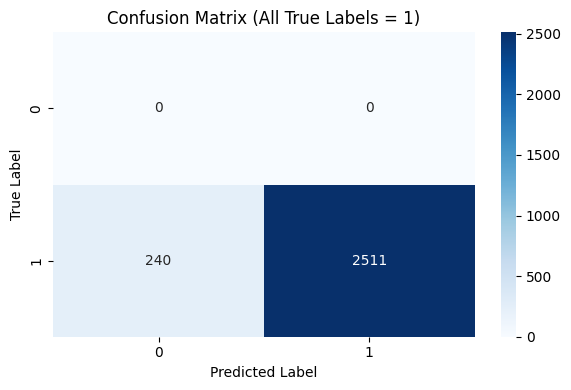


Metric Explanations:
Accuracy: % of compounds correctly identified (% predicted as fragrant)
Precision: Always 1.0 when all true labels are 1 (all positive predictions are correct)
Recall: % of fragrant compounds identified (same as accuracy)
F1 Score: Harmonic mean of precision and recall

Out of 2751 compounds (all assumed fragrant):
- Correctly identified as fragrant (True Positives): 2511
- Incorrectly identified as non-fragrant (False Negatives): 240

Predictions and metrics saved to 'data/fragrance_datasets/arctander/arctander_predictions.xlsx'


In [23]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import seaborn as sns

# Function to plot confusion matrix
def plot_confusion_matrix(cm, classes, title='Confusion Matrix', cmap=plt.cm.Blues):
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

# Load the saved model and scaler
model = joblib.load('frag_likeliness_model.joblib')
scaler = joblib.load('feature_scaler.joblib')

# Get the top features and coefficients
coefficients = model.coef_[0]
intercept = model.intercept_[0]

# Top 5 features from your previous code
top_feature_names = ['logP',
                     'Molecular Weight',
                     'SlogP_VSA3',
                     'Fraction of Sp2 Hybridized Atoms',
                     'FCFP4 Count']

# Print the equation
equation = f"frag_likeliness = {intercept:.4f}"
for feature, coef in zip(top_feature_names, coefficients):
    equation += f" + ({coef:.4f} * {feature})"
print("\nPrediction Equation:")
print(equation)

# Load the actual dataset
file_path = 'data/fragrance_datasets/arctander/arctander_molecular_properties.xlsx'
try:
    data = pd.read_excel(file_path)
    print(f"Successfully loaded {file_path}")
    print(f"Dataset contains {len(data)} samples")
except Exception as e:
    print(f"Error loading file: {e}")
    exit()

# Check if all required features are present
missing_features = [f for f in top_feature_names if f not in data.columns]
if missing_features:
    print(f"Warning: Missing features in dataset: {missing_features}")
    print("Please ensure your dataset contains all these features.")
    exit()

# Select only the top 5 features
X = data[top_feature_names]

# Ensure all features are numeric
X = X.select_dtypes(include=[np.number])

# Scale the features using the same scaler
X_scaled = scaler.transform(X)

# Manual calculation using the equation
z_values = intercept + np.dot(X_scaled, coefficients)
probabilities = 1 / (1 + np.exp(-z_values))
predictions = (probabilities >= 0.5).astype(int)

# Summary statistics of predicted probabilities
print("\nPredicted Probability Statistics:")
print(f"Min: {probabilities.min():.4f}")
print(f"Max: {probabilities.max():.4f}")
print(f"Mean: {probabilities.mean():.4f}")
print(f"Median: {np.median(probabilities):.4f}")
print(f"Standard Deviation: {np.std(probabilities):.4f}")

# Count of positive predictions
positive_count = np.sum(predictions)
total_count = len(predictions)
print(f"Positive predictions: {positive_count}/{total_count} ({positive_count/total_count:.2%})")

# # Create a histogram of the probabilities
# plt.figure(figsize=(10, 6))
# plt.hist(probabilities, bins=20, alpha=0.7, color='blue')
# plt.axvline(x=0.5, color='red', linestyle='--', label='Decision Threshold (0.5)')
# plt.xlabel('Predicted Probability of Being Fragrant')
# plt.ylabel('Count')
# plt.title('Distribution of Predicted Fragrance Probabilities')
# plt.legend()
# plt.grid(axis='y', alpha=0.3)
# plt.tight_layout()
# plt.show()

# Assign all true labels as 1
all_ones = np.ones(len(predictions))

# Calculate performance metrics
accuracy = accuracy_score(all_ones, predictions)
precision = precision_score(all_ones, predictions, zero_division=1)
recall = recall_score(all_ones, predictions, zero_division=1)
f1 = f1_score(all_ones, predictions, zero_division=1)

print("\nPerformance Metrics (assuming all true labels are 1):")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Create confusion matrix
cm = confusion_matrix(all_ones, predictions)
plot_confusion_matrix(cm, classes=[0, 1], title='Confusion Matrix (All True Labels = 1)')

# Explanation of metrics
print("\nMetric Explanations:")
print("Accuracy: % of compounds correctly identified (% predicted as fragrant)")
print("Precision: Always 1.0 when all true labels are 1 (all positive predictions are correct)")
print("Recall: % of fragrant compounds identified (same as accuracy)")
print("F1 Score: Harmonic mean of precision and recall")

# Detailed breakdown of predictions
false_negatives = total_count - positive_count
print(f"\nOut of {total_count} compounds (all assumed fragrant):")
print(f"- Correctly identified as fragrant (True Positives): {positive_count}")
print(f"- Incorrectly identified as non-fragrant (False Negatives): {false_negatives}")

# Add predictions to the dataset
data['frag_likeliness_prediction'] = predictions
data['frag_likeliness_probability'] = probabilities
data['frag_likeliness_z_value'] = z_values

# Save the predictions to a new file
output_path = 'data/fragrance_datasets/arctander/arctander_predictions.xlsx'
data.to_excel(output_path, index=False)
print(f"\nPredictions and metrics saved to '{output_path}'")